# Stage 12 — Mars threshold and prediction analysis

_Pipeline stage 12 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Threshold sensitivity — the scientific knob on label-free Mars

Mars has no ground truth, so the coupling *rate* depends on the chosen threshold. We
sweep it and report how the coupled fraction responds per regime. A trustworthy
conclusion is **stable** across a sensible band and **consistent** across regimes —
not an artifact of one cut.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


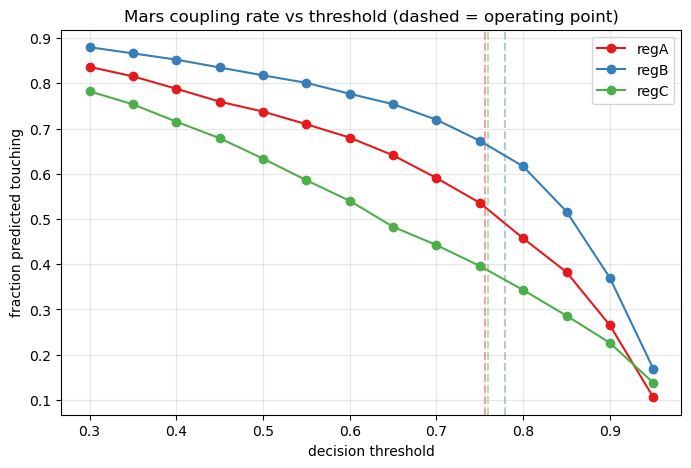

In [2]:
SWEEP = np.round(np.arange(0.30, 0.96, 0.05), 2)
fig, ax = plt.subplots(figsize=(8, 5))
for r, col in zip(REGIMES_, ['#e41a1c', '#377eb8', '#4daf4a']):
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if p.exists():
        pr = pd.read_parquet(p).prob_touching.to_numpy()
        ax.plot(SWEEP, [(pr >= t).mean() for t in SWEEP], 'o-', color=col, label=r)
        ax.axvline(OP_THR[r], color=col, ls='--', alpha=0.4)
ax.set_xlabel('decision threshold'); ax.set_ylabel('fraction predicted touching')
ax.set_title('Mars coupling rate vs threshold (dashed = operating point)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

Smooth curves near the operating points -> the precision-oriented choice is stable;
regB > regA > regC at every threshold -> the regime *ordering* of coupling is robust.
Deep dive: `notebooks/mars/05_mars_threshold_sensitivity.ipynb`.